In [1]:
import pandas as pd
df_original = pd.read_excel("../data/raw/Dry_Bean_Dataset.xlsx")
df_original.to_csv("../data/raw/Dry_Bean.csv", index=False)
print("CSV creado:", df_original.shape)     

CSV creado: (13611, 17)


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Cargar el archivo CSV desde la carpeta data/raw/
df = pd.read_csv("../data/raw/Dry_Bean.csv")

# 2. Eliminar filas duplicadas
df_clean = df.drop_duplicates().reset_index(drop=True)

# 3. Limpiar espacios en la columna Class
df_clean["Class"] = df_clean["Class"].astype(str).str.strip()

# 4. Confirmar cuantas filas quedaron
print(f"Filas listas para el EDA: {df_clean.shape[0]}")
print("\nDistribución de las clases limpias:")
print(df_clean["Class"].value_counts())

# Mostrar las primeras filas
df_clean.head()

Filas listas para el EDA: 13543

Distribución de las clases limpias:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1860
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


C:\Users\Usuario\AppData\Local\Temp\ipykernel_19964\2547154992.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


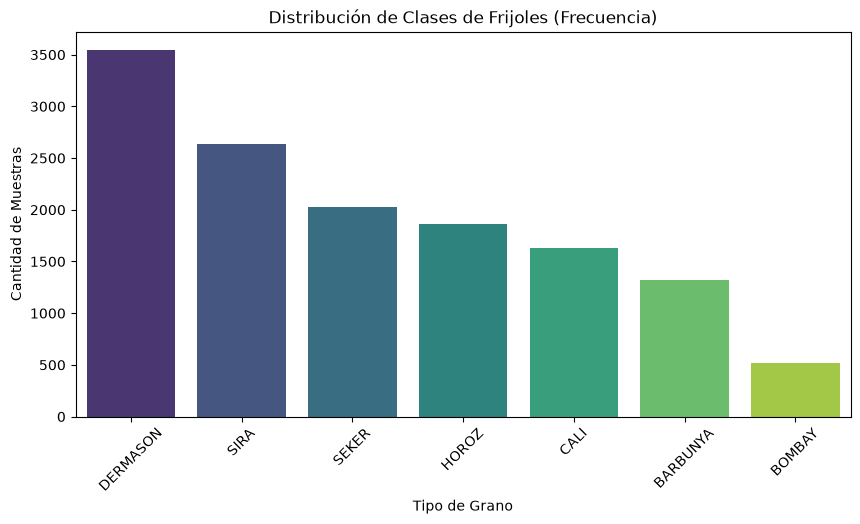

In [3]:
# Gráfico de barras para ver la distribución de cada clase de grano
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df_clean,
    x="Class",
    order=df_clean["Class"].value_counts().index,
    palette="viridis",
)
plt.title("Distribución de Clases de Frijoles (Frecuencia)")
plt.xlabel("Tipo de Grano")
plt.ylabel("Cantidad de Muestras")
plt.xticks(rotation=45)
plt.show()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_19964\1228121029.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


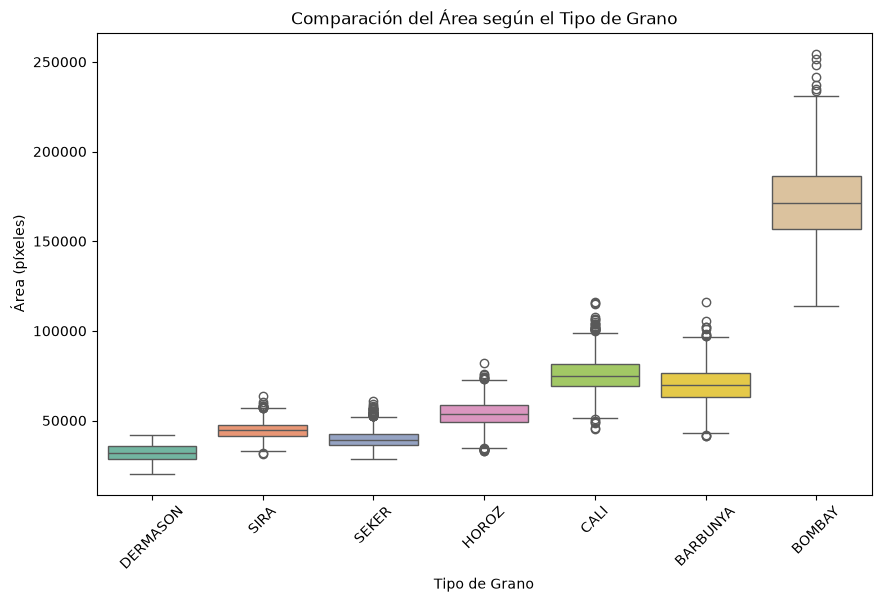

In [4]:
# Boxplot de Área por Clase
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_clean,
    x="Class",
    y="Area",
    order=df_clean["Class"].value_counts().index,
    palette="Set2",
)
plt.title("Comparación del Área según el Tipo de Grano")
plt.xlabel("Tipo de Grano")
plt.ylabel("Área (píxeles)")
plt.xticks(rotation=45)
plt.show()

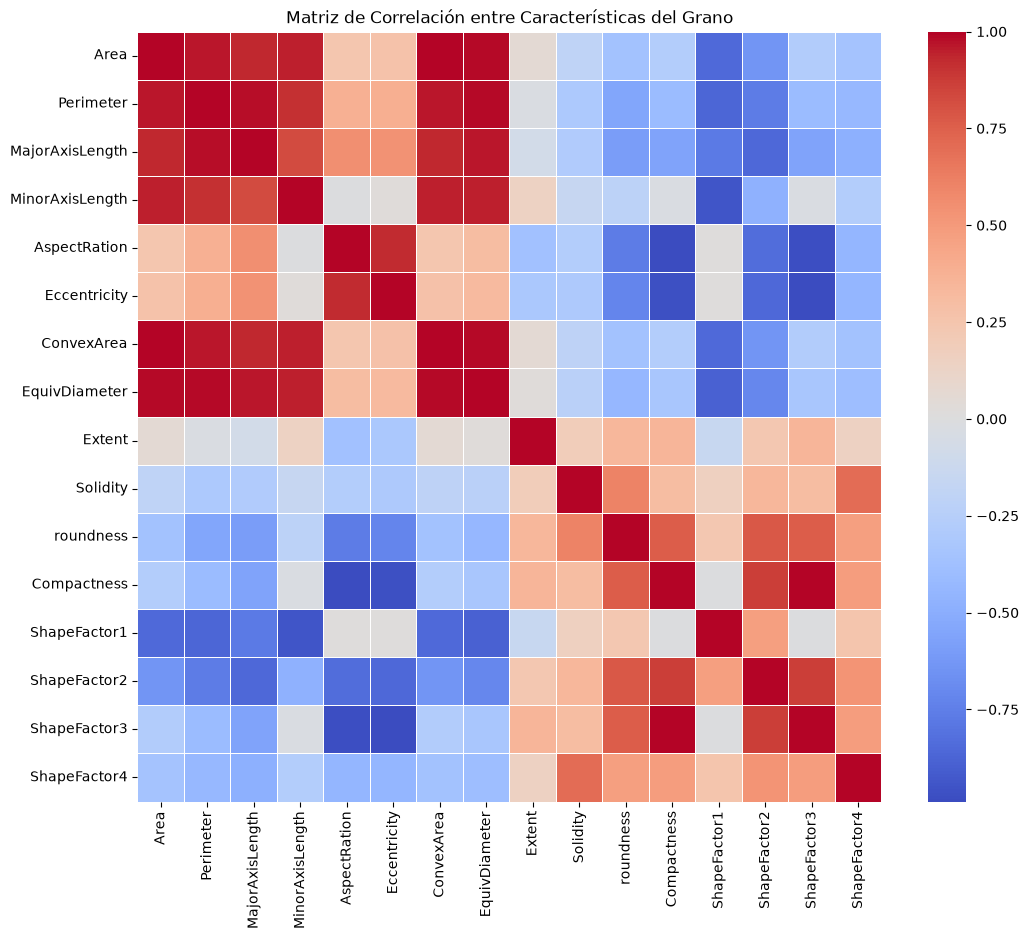

In [5]:
# Matriz de Correlación entre las características numéricas
plt.figure(figsize=(12, 10))

# Calculamos la matriz excluyendo la columna categórica 'Class'
matriz_corr = df_clean.drop("Class", axis=1).corr()

# Dibujamos el mapa de calor
sns.heatmap(matriz_corr, annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Matriz de Correlación entre Características del Grano")
plt.show()

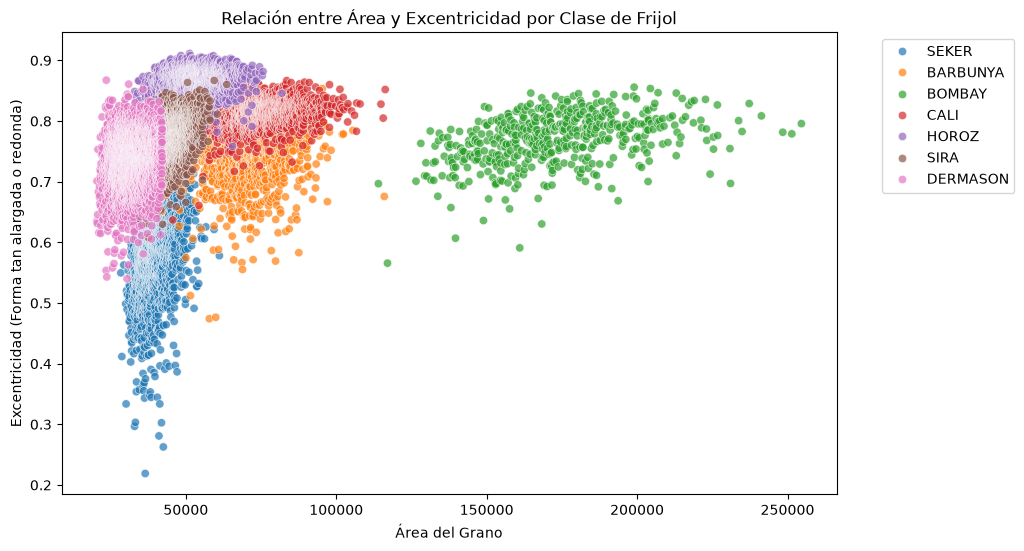

In [6]:
# Gráfico de dispersión para ver cómo interactúan el Área y la Excentricidad
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean,
    x="Area",
    y="Eccentricity",
    hue="Class",
    alpha=0.7,
    palette="tab10",
)
plt.title("Relación entre Área y Excentricidad por Clase de Frijol")
plt.xlabel("Área del Grano")
plt.ylabel("Excentricidad (Forma tan alargada o redonda)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

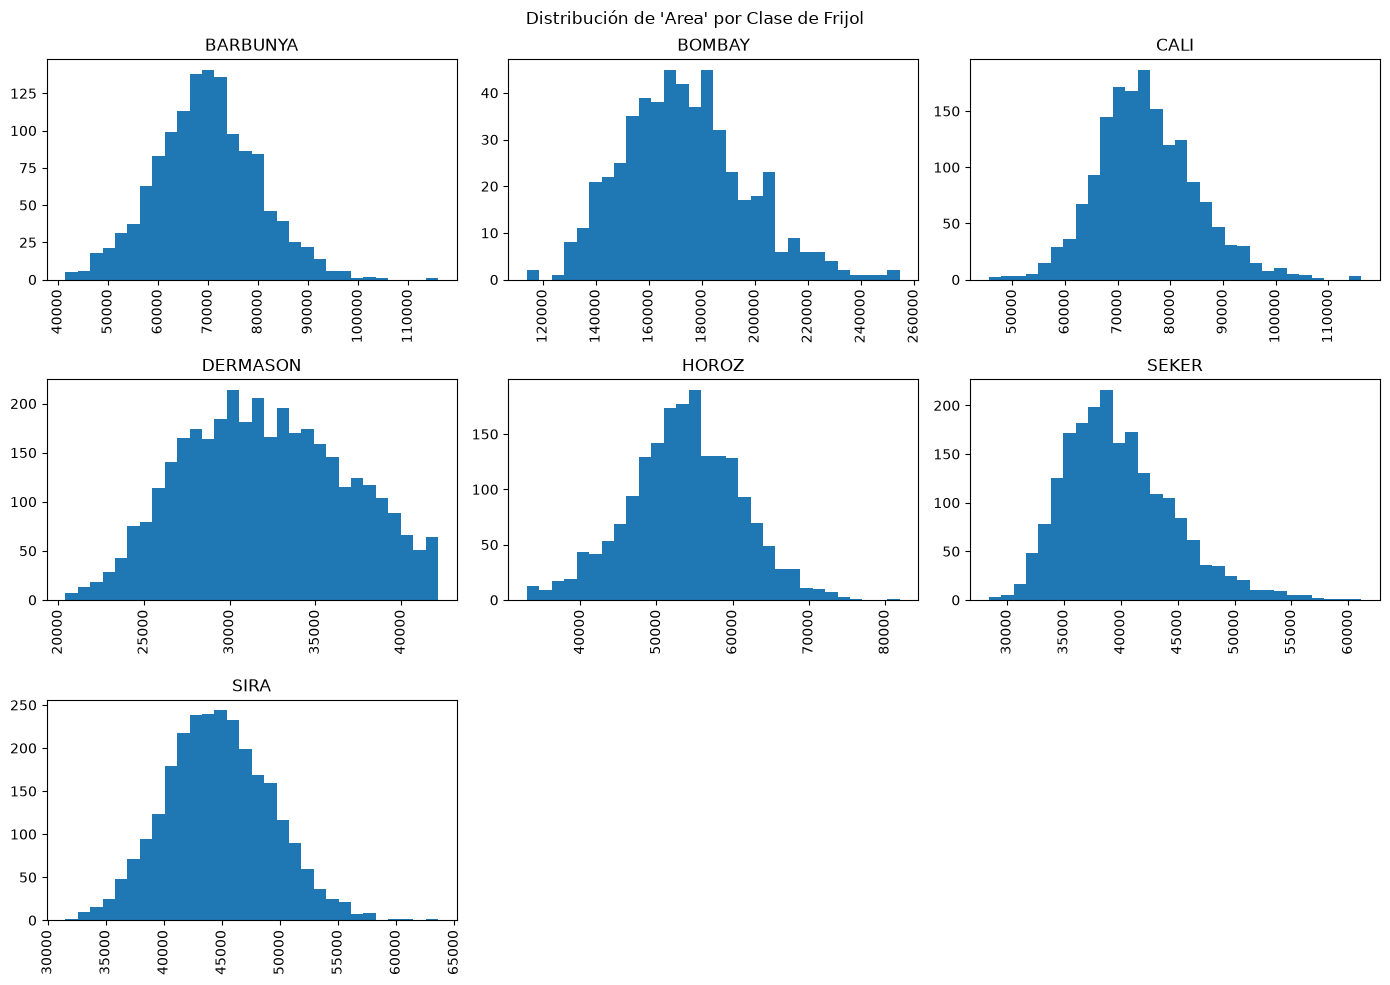

In [7]:
# Histograma de una variable clave (Area) separado por clase
df_clean[["Area", "Class"]].hist(by="Class", figsize=(14, 10), bins=30)
plt.suptitle("Distribución de 'Area' por Clase de Frijol")
plt.tight_layout()
plt.show()

In [8]:
import os
os.makedirs("../data", exist_ok=True)
df_clean.to_csv("../data/dry_bean_clean.csv", index=False)
print(f"Guardado: {df_clean.shape[0]} filas, {df_clean.shape[1]} columnas")

Guardado: 13543 filas, 17 columnas
